In [1]:
# Import libraries
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import missingno as msno


train_csv = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/train.csv')
test_csv = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/test.csv')

train_csv.sample(5)

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
486048,486048,61,72636.0,54.6,2,3,1,2.0,Female,Suburban,Hatchback,Yes,Yes,Low,No
144632,144632,41,44929.0,21.3,1,2,8,4.0,Male,Suburban,Truck,Yes,Yes,Low,No
654501,654501,50,110411.0,5.0,3,0,0,5.0,Female,Rural,Hatchback,Yes,Yes,Low,Yes
603120,603120,67,73979.0,40.6,1,6,1,2.0,Male,Suburban,Hatchback,Yes,No,Low,No
406035,406035,52,88041.0,58.8,2,0,1,4.0,Male,Rural,Sedan,Yes,Yes,Low,Yes


In [2]:
# View train dataset
train_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

<Axes: >

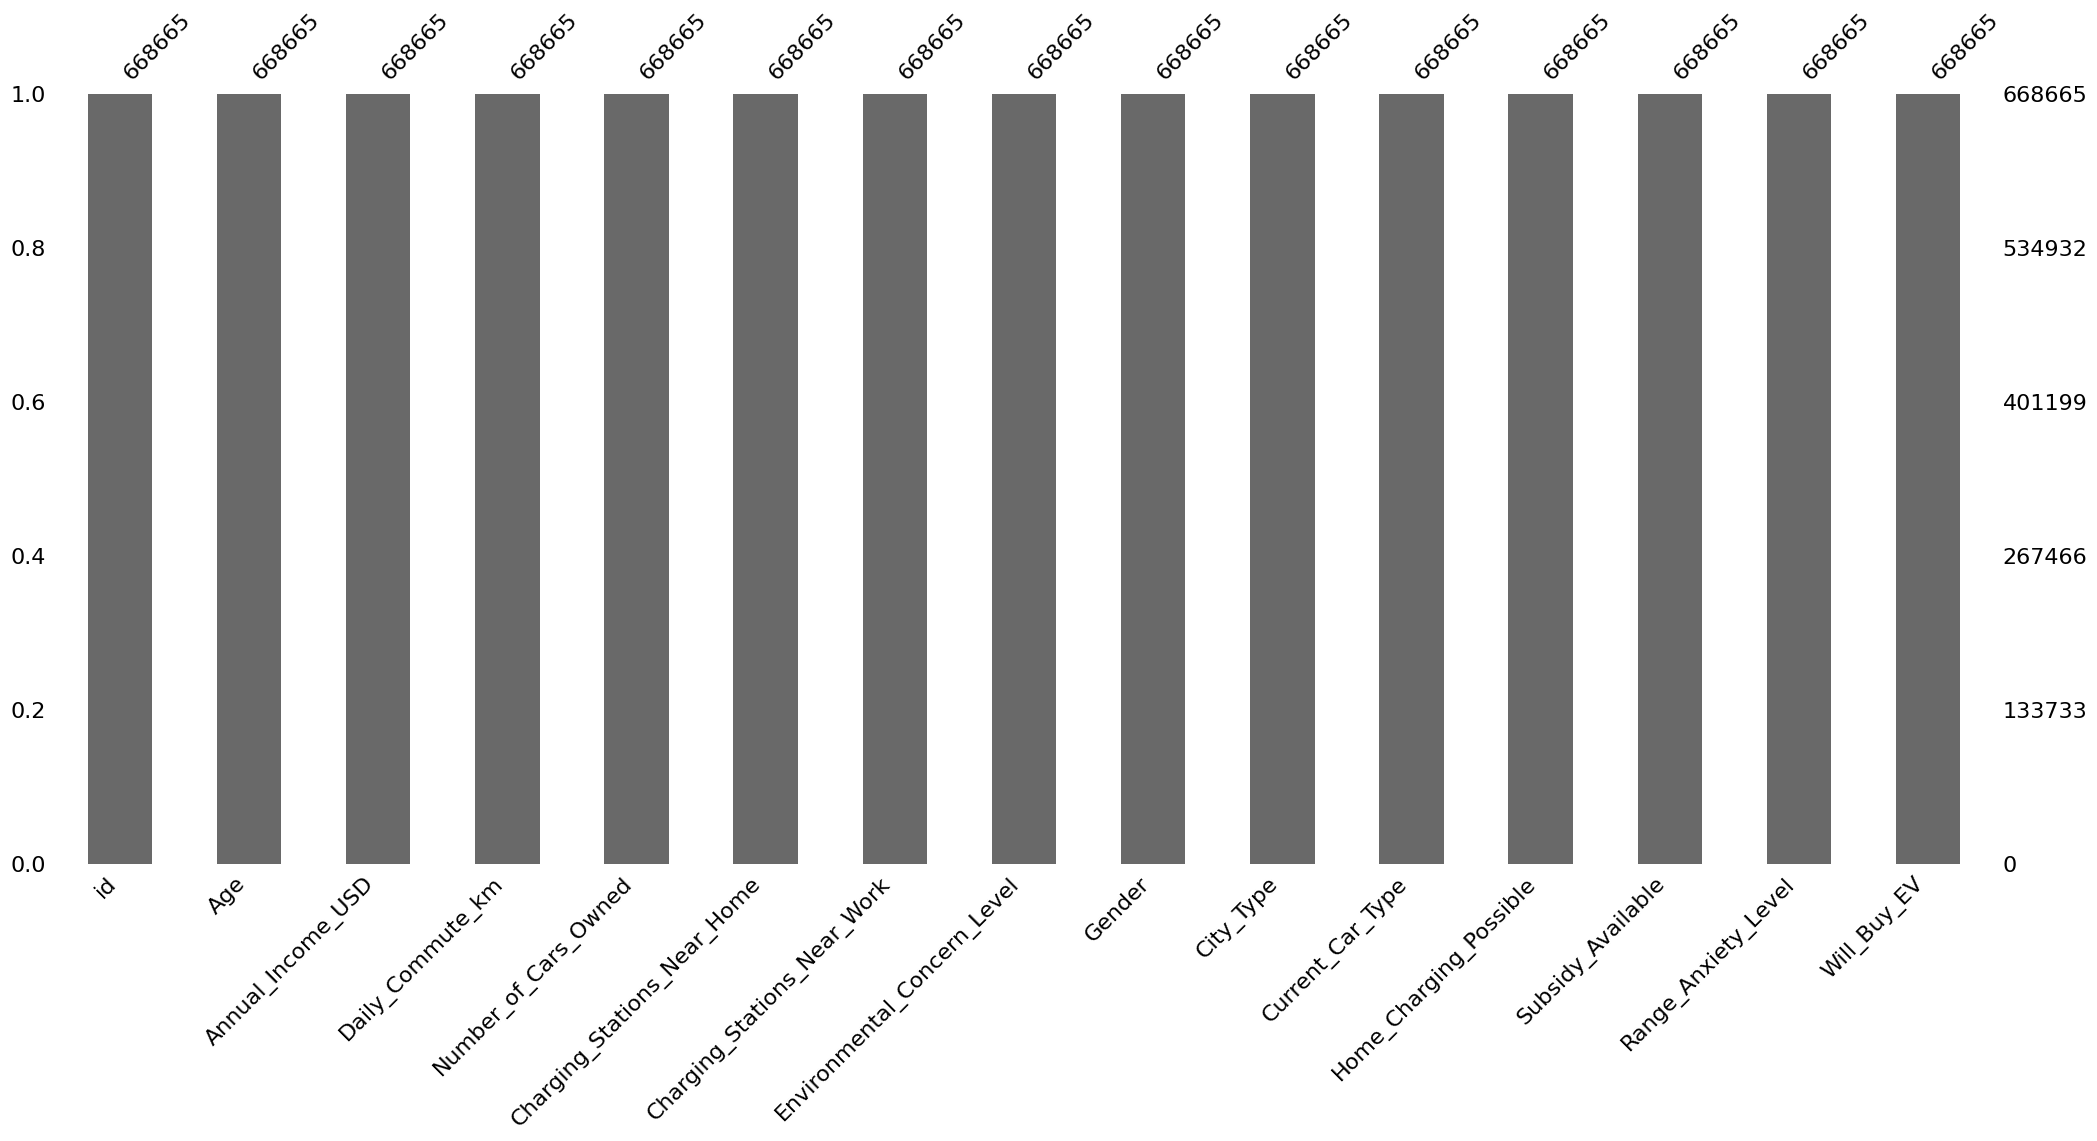

In [3]:
# Check missing values
msno.bar(train_csv)

In [4]:
# Target distribution proportion
yes_target = train_csv['Will_Buy_EV'].value_counts(normalize=True)


print(f' The percentage distribution for: {(yes_target * 100)}')

 The percentage distribution for: Will_Buy_EV
No     82.5355
Yes    17.4645
Name: proportion, dtype: float64


In [5]:
# Look closely at the numerical columns
train_csv.describe().T

,count,mean,std,min,25%,50%,75%,max
id,668665.0,334332.000000,193027.103210,0.0,167166.0,334332.0,501498.0,668664.0
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0


In [6]:
#Feature Engineering
# The plus one is to prevent errors from those who have 0 number of owned cars in the future
train_csv['Yearly_Income_to_Vehicle_Ratio'] = (train_csv['Annual_Income_USD'] / (train_csv['Number_of_Cars_Owned'] + 1))
train_csv['Yearly_Income_to_Vehicle_Ratio']

0         30962.333333
1         15000.000000
2         47194.500000
3         24526.666667
4         28949.000000
              ...     
668660    23696.666667
668661    43330.000000
668662    60895.500000
668663    38641.000000
668664    34493.000000
Name: Yearly_Income_to_Vehicle_Ratio, Length: 668665, dtype: float64

In [7]:
# Split age into demographic groups
# Youth 25 - 35, Middle Age 36 - 50, Senior 51 - 65, Elder 66+
train_csv.loc[(train_csv['Age'] > 24) & (train_csv['Age'] < 36) , ['Age_Group']] = 'Youth'
train_csv.loc[(train_csv['Age'] > 35) & (train_csv['Age'] < 51) , ['Age_Group']] = 'Middle-Age'
train_csv.loc[(train_csv['Age'] > 50) & (train_csv['Age'] < 65) , ['Age_Group']] = 'Senior'
train_csv.loc[(train_csv['Age'] > 65) , ['Age_Group']] = 'Elder'

train_csv.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,Yearly_Income_to_Vehicle_Ratio,Age_Group
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No,30962.333333,Elder
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No,15000.000000,Middle-Age
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes,47194.500000,Youth
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No,24526.666667,Elder
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No,28949.000000,Senior
